# Cadre metier, EDA et Audit


# Cadre Métier

## Contexte

Le churn constitue un enjeu majeur pour les entreprises de services, en particulier les entreprises de télécommunications où les concurrences sont fortes, et où le coût d'acquisitions d'un nouveau clients est largement plus coûteux que la rétention d'un client existant. Dans ce contexte il est important d'identifier les clients susceptibles de résilier leur contrat, de comprendre les facteurs qui sont liés à cette résiliation et de formuler des actions de rétention ciblées à partir des données   

## Définition du Churn dans ce dataset

Dans ce projet le churn designe la résiliation du service par le client. Et dans le dataset, la variable cible `Churn` designe si le client à quitter le Service ( `Yes`) ou il est resté (`No`).

## Formulation du probléme

Le projet est formulé comme un problème de classification binaire supervisée. L'objectif est de prédire, à partir des caractéristiques des clients s'ils sont à risque de churn ou non.

## Valeur Business d'un bon Modéle

Un bon modèle de churn est celui qui aide à identifier, de manière claire les clients qui sont plus à risque, afin de permettre l'entreprise à mieux prioriser ses actions commerciales, ses offres de rentention et ses interventions support. L'enjeu n'est pas seulement de prédire mais c'est aussi et surtout de permettre la décision. 

## Rôle des faux positifs et faux négatifs:
Un **faux positif** correspond à un client prédit comme une personne qui va quitter l'entreprise, alors qu'il ne quitte pas vraiment. Cela conduit à des actions de retentions inutiles, donc ressources allouées à pertes.  
Un **faux négatif**  correspond à un client qui est prédit comme non risqué alors qu'il finit par effectivement résilier son contrat. Ce qui constitue une erreur coûteuse car l'entreprise perd un client sans avoir pu entreprendre des actions de rétension

## Objetifs et questions metier:
1. Quels sont les clients à haut risque?
2. Quels sont les facteurs qui expliquent le churn?
3. Parmis ces facteurs les quels sont actionnables?
4. Quelles recommandation business proposer pour reduire le churn?

# Audit et EDA

In [1]:
##==== Importation de modules essentiels ============#
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [2]:
##============= Chargement de données ============
# Réglages d'affichage
pd.set_option("display.max_columns", 21)
# Toujours afficher la dimension du dataframe
pd.set_option("display.show_dimensions", True)

# Chemin absolue

project_root = Path.cwd().resolve().parents[0]
src_path = project_root / "src"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

## import projet
from src.config import RAW_DATA_PATH, RAW_DATA_DIR
from src.utils import load_csv

In [3]:
df_raw = load_csv(RAW_DATA_PATH)
df = df_raw.copy()

## Analyse de structure:
- **Dimensions du dataset** : notre dataset compte 7043 lignes et 21 colonnes
- **Type de chaque variable** : On a donc 18 variables de type categorielles ou object et une variable de type float ou           flotante et deux variables de type entier
- **Valeurs manquantes** : On remarque notre dataset compte peu de valeurs manquantes, justee 11 valeurs valeurs manquantes       sur la variable `TotalCharges`. 
- **Doublons** : On observe 0 doublons dans notre dataset
- **Cardinalités des variables catégorielles** : On observe qu'on a 7 variables avec deux modalités (gender, Partener,            Dependents,PhoneService, churn, PaperlessBilling, SeniorCitizen), 9 variables avec trois modalités (MultiplesLines,            InternetService,OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, SreamingTV, StreamingMovies, Contract) et 1       avec quatre modalités (PaymentMethod)  
- **Cohérence générale des données** : Globalement on a une bonne cohérence des données.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
#df.dtypes.astype(str).to_dict()
df.dtypes.value_counts()

object     18
int64       2
float64     1
Name: count, Length: 3, dtype: int64

<Axes: ylabel='count'>

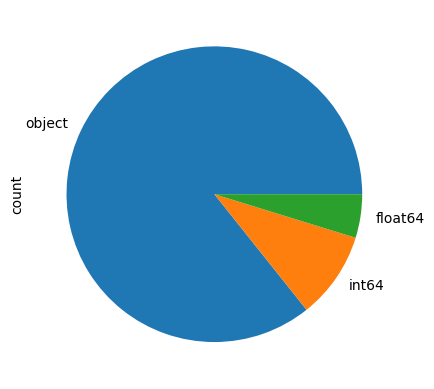

In [7]:
df.dtypes.value_counts().plot.pie()

In [8]:
df["TotalCharges"] = df["TotalCharges"].replace( " ", np.nan)

In [9]:
df.isna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<function matplotlib.pyplot.show(close=None, block=None)>

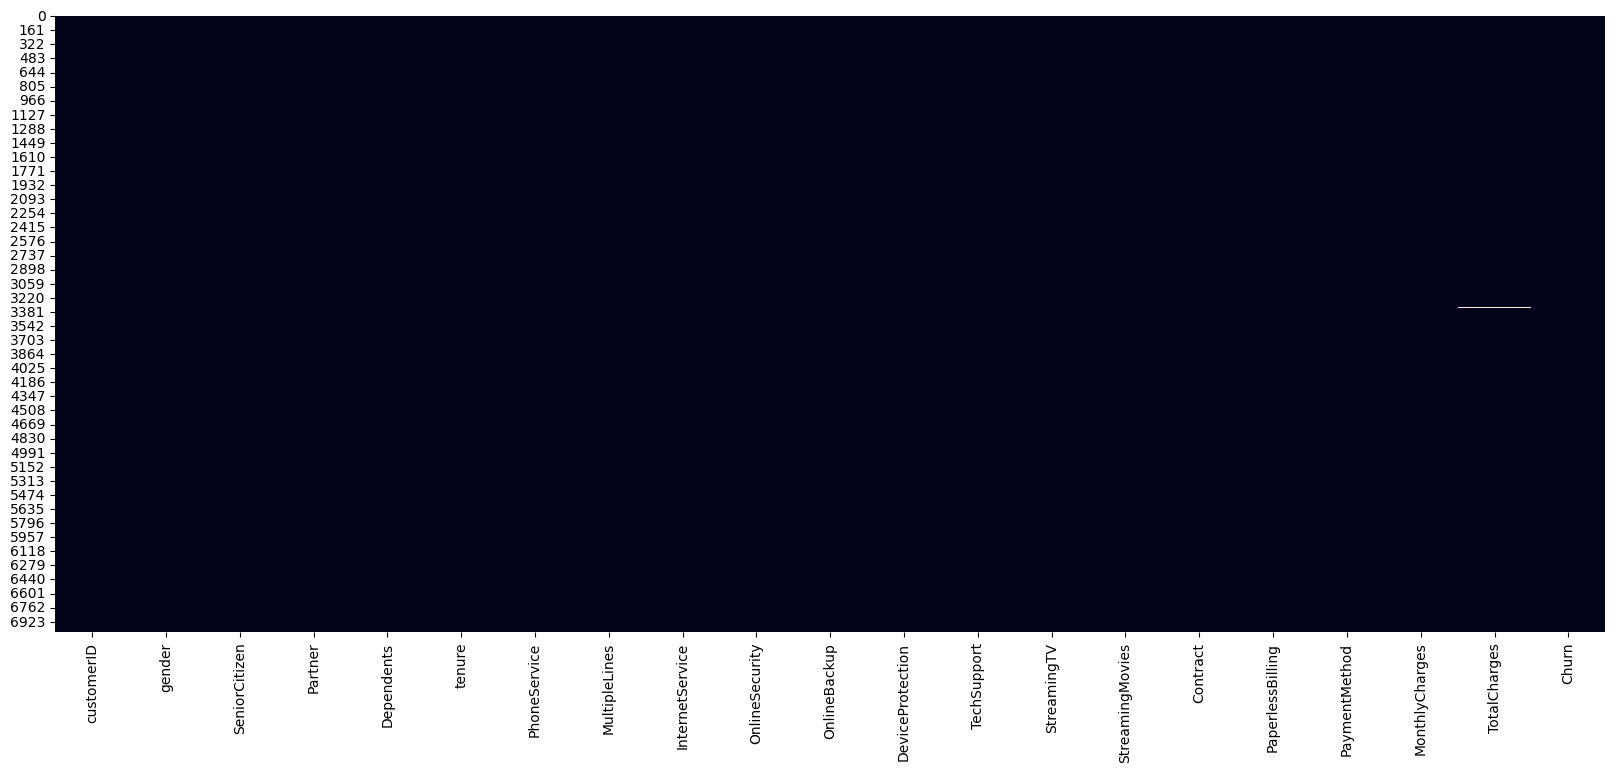

In [10]:
##============== Visualisation des valeurs manquantes ==============
plt.figure(figsize= (20,8))
sns.heatmap(df.isna(), cbar=False)
plt.show

In [11]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
Length: 21, dtype: int64

In [12]:
##=============== Verification de doublons =================

int(df.duplicated().sum())

0

In [13]:
##=========== cardinalité des variables catégorielles ============#

for col in df.select_dtypes("object").columns:
    print(f'{col :-<50} {df[col].unique()}')

customerID---------------------------------------- ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender-------------------------------------------- ['Female' 'Male']
Partner------------------------------------------- ['Yes' 'No']
Dependents---------------------------------------- ['No' 'Yes']
PhoneService-------------------------------------- ['No' 'Yes']
MultipleLines------------------------------------- ['No phone service' 'No' 'Yes']
InternetService----------------------------------- ['DSL' 'Fiber optic' 'No']
OnlineSecurity------------------------------------ ['No' 'Yes' 'No internet service']
OnlineBackup-------------------------------------- ['Yes' 'No' 'No internet service']
DeviceProtection---------------------------------- ['No' 'Yes' 'No internet service']
TechSupport--------------------------------------- ['No' 'Yes' 'No internet service']
StreamingTV--------------------------------------- ['No' 'Yes' 'No internet service']
StreamingMov

In [14]:
##============= Suppression de "customerID" & conversion de "TotalCharges" ==============

df=df.drop('customerID', axis=1)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
###======= Cohérence générale des données ==========

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [16]:
##================== Statistiques descriptives ==================

df.describe(include = "number").T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [17]:
##================= Statistiques descriptives =================

num_summary_by_churn = df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median", "std"])
num_summary_by_churn.to_csv("../reports/tables/numeric_summary_by_churn.csv")
num_summary_by_churn

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                        
              mean   median          std  
Churn                                     
No     2555.344141  1683.60  2329.456984  
Yes    1531.796094   703.55  1890.822994  

[2 rows x 9 columns]

In [18]:
##================== Statistiques descriptives ==================

df.describe(include = "object").T

,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473


In [19]:
##================= Nombre de modalités par caractéristique =================

df.nunique().sort_values(ascending = False)


TotalCharges        6530
MonthlyCharges      1585
tenure                73
PaymentMethod          4
DeviceProtection       3
Contract               3
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
TechSupport            3
StreamingTV            3
StreamingMovies        3
PaperlessBilling       2
gender                 2
SeniorCitizen          2
PhoneService           2
Dependents             2
Partner                2
Churn                  2
Length: 20, dtype: int64

## Analyse de variable target
- **distribution** : la distribution de la variable cible `Churn` montre une répartition déséquilibrée des deux classes 
- **Déséquilibre de classe** : On observe une déséquilibre nette entre la classe `No`, qui regroupe 5174 clients environ 73%     du dataset  et la classe `Yes`, qui compte lui 1869, soit environ 26% du dataset. On obsérve donc une déséquilibre nette       entre les deux classes
- **Taux globale de churn** : Le taux de churn est environ 26%, ce qui n'est pas négligeable.

### Étude de la variable cible

In [20]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, Length: 2, dtype: int64

In [21]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, Length: 2, dtype: float64

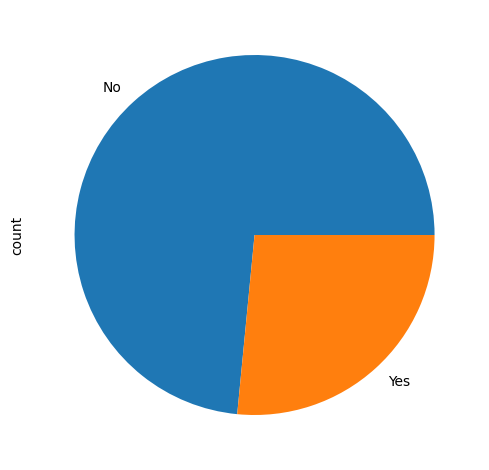

In [24]:
##========= Distribution de la variable cible sous forme de diagramme circulaire ==============##

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df["Churn"].value_counts().plot.pie()

plt.tight_layout()
plt.savefig(figures_dir / "churn_dist.png", bbox_inches="tight")
plt.show()


# Analyse univariée et bivariée

## Analyse univariée
- **Variables numeriques** :
   - la distribution de la variable `tenure` est très asymétrique à droite, avec une forte concentration des clients ayant une     faible ancienneté, ce qui peut suggérer le fait que de nombreux clients soient récents. un phénomène qui peut favoriser le     risque de churn
   - La distribution des charges mensuelles sont relativement étalées, cela peut être dû à une diversité tarifaire. certains       valeurs élevées peut reflète sûrement à une souscription à plusieurs services (ce qui peut montrer un engagement plus          fort).
   - des outliers ou valeurs aberrantes sont observées sur certaines variables numériques particulièrement avec les variables      `MonthlyCharges` et `TotalCharges`, ce qui est compréhensible dans un contexte métier (offre speciales ou forte                ancienneté). Ces outliers contituent une information en sois, qu'ils seraient imprudent de supprimer sans précaution.
- **Variables catégorielles** :
    - on observe une proportion quasi-equivalent de femmes et de hommes et pareil pour les clients avec des partenaires           (48,3%), autrement dit que près de la moitié de clients du service Telecom ont une stabilité résidentielle ce qui peut-être     un avantage pour la rétention du client.
    - Cependant on remarque que les clients qui ont des personnes qui dépendent d'eux (famille,...) est moins important environ
      30%
    -  On observe aussi quelque chose qui est très intéressante est que 90,3% des clients l'entreprise sont abonnés à un            services téléphoniques, cependant la proportion de clients abonnés avec des lignes multiples (42,2% environ) est un peu        moins, deux caractéristiques très intéressantes montrant un nombre importante de clients avec des engagements                  relativement solides
    - On observe aussi que 78,4% des clients sont abonnés à un servercice internet (fibre ou DSL) ce qui peut être très               intéressant pour l'entreprise pour la rétention des clients si c'est bien utilisé, en plus un bon fonctionnement de          cet offre de service demeure capitale car la quasi-totalités des services additionnels en dépendent (l'ensemble                des services en ligne, nécessitant de l'internet).
    - Cependant les abonnements sur les services additionnels sont moyens importants quasiment tous, sont en dessous des 50%        (TechSupport, OnelineBackup, OnelineSecurity, StreamTV, StreamMovies, DeviceProtection)
    - Pour les types de contrat on observe que plus de la majorité des clients sont engagés sur des contrats mensuels, ce qui       n'est pas très rassurante car moins solide ou durable, cela peut influencer négativement sur la capacité de retenir les        clients, cependant on observe une chose qui peut être intéressante est que le nombre de clients avec des contrats de 2         ans est plus important (24,1%), comparé des contrats annuels (20,9%)
    - On observe en fin que le mode de paiement le plus utilisé par les clients est le paiement par chèque électronique

In [24]:
##======== Division de mon dataframe ==========
churner_df=df[df["Churn"]== "Yes"]
non_churner_df=df[df["Churn"]== "No"]

In [25]:
#churner_df

In [26]:
#non_churner_df

In [27]:
##======== Création d'ensembles profile_clients, services_souscr_equ, dimension_fin =========
profiles_clients = list(["gender", "SeniorCitizen", "Partner", "Dependents"])
services_souscr_equ = list(["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
                           "StreamingTV", "StreamingMovies"])
dimensions_fin = list(["PaperlessBilling", "PaymentMethod"])
charges_clients= list(["MonthlyCharges", "TotalCharges", "tenure"])



### **Visualisation des variables numériques/ Catégorielles**

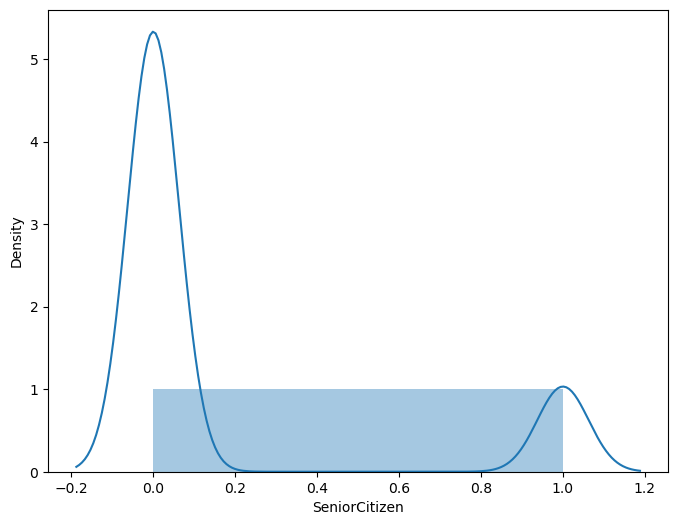

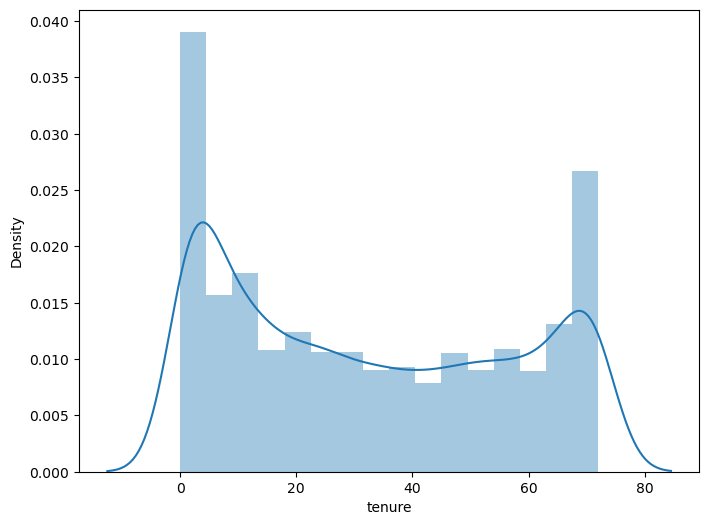

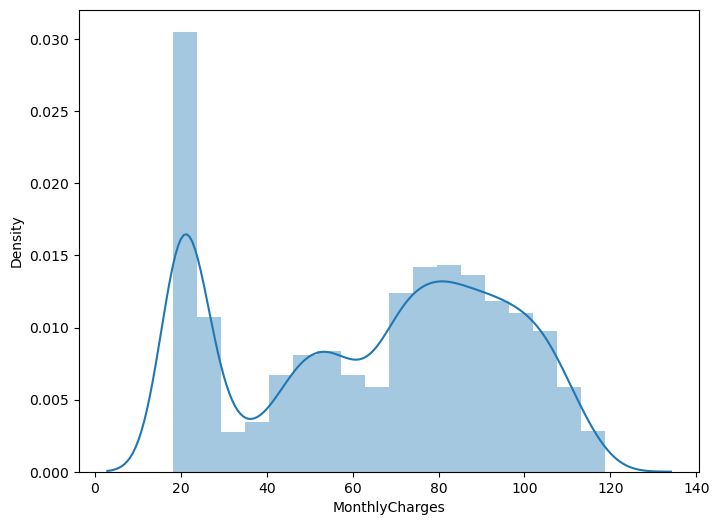

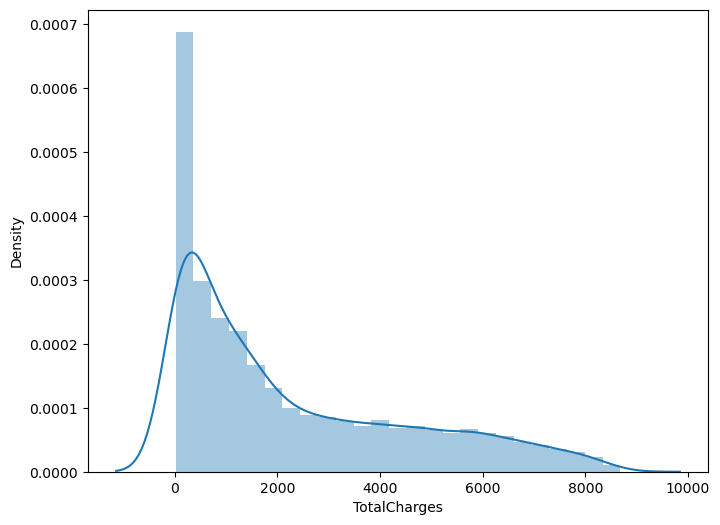

In [28]:
##======= Visulalisation des variables numeriques =============

for col in df.select_dtypes(include=["number"]):
    plt.figure(figsize=(8, 6))

    sns.distplot(df[col], kde=True, bins= "fd")
    plt.show()

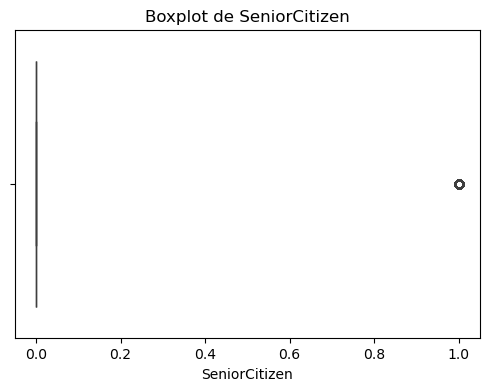

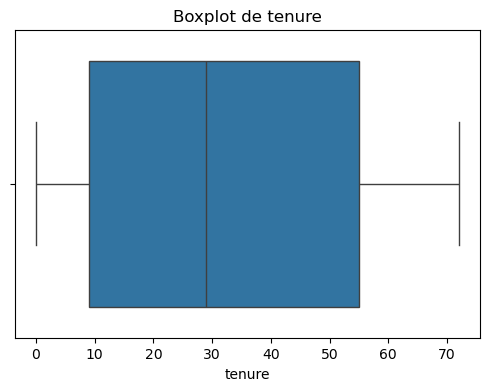

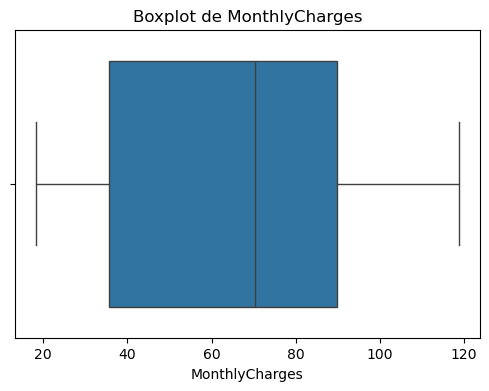

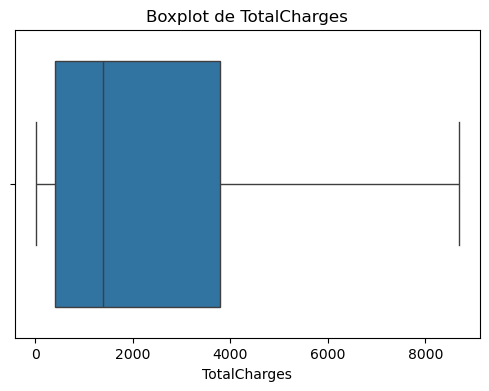

In [29]:
#==== Visualisation des outliers via boxplot =========

for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()



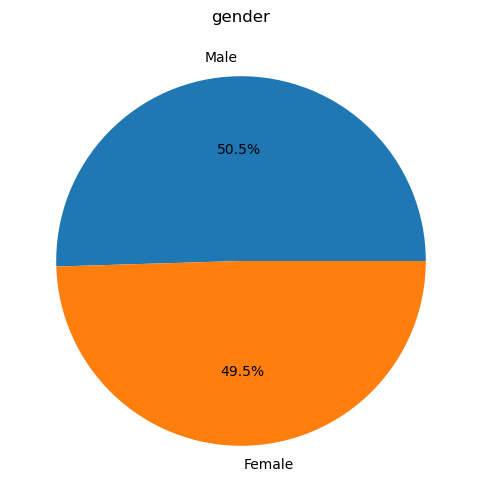

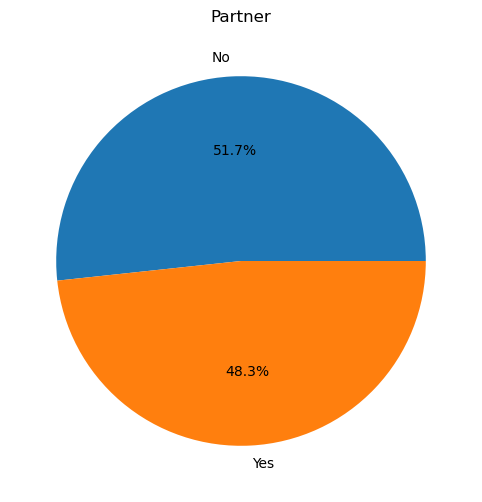

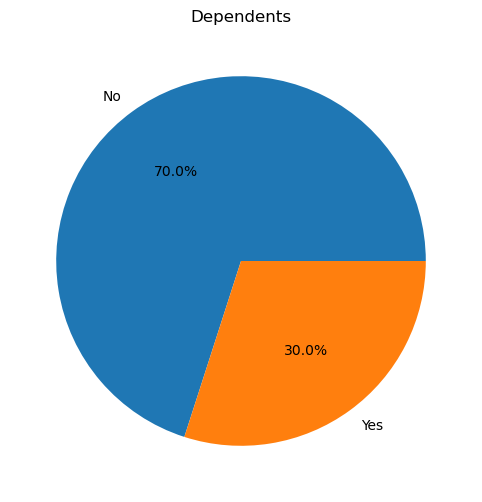

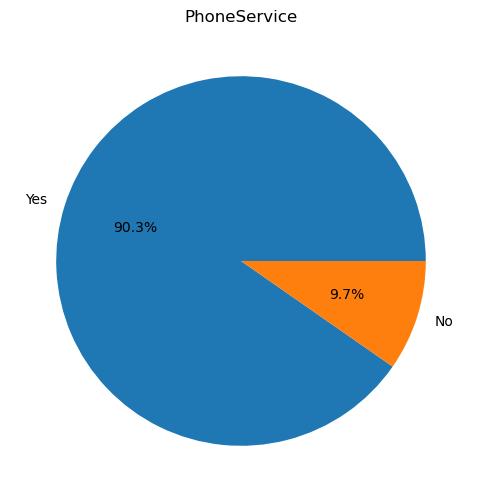

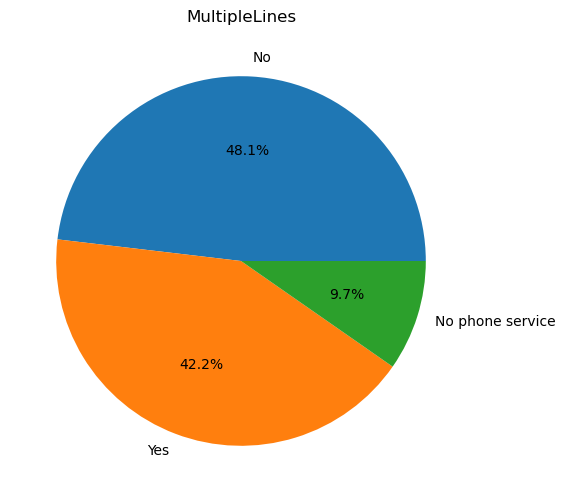

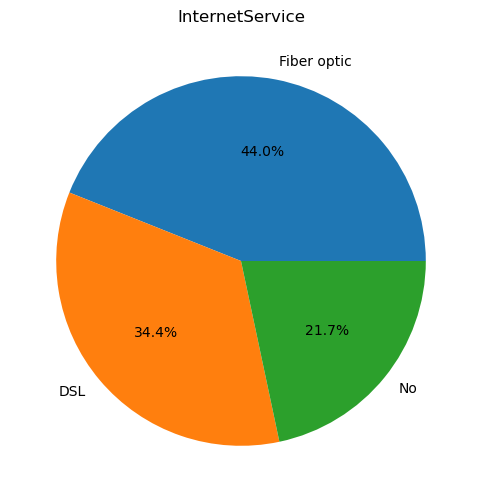

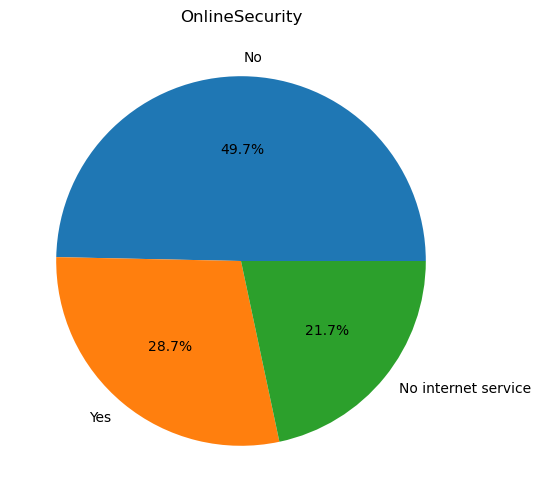

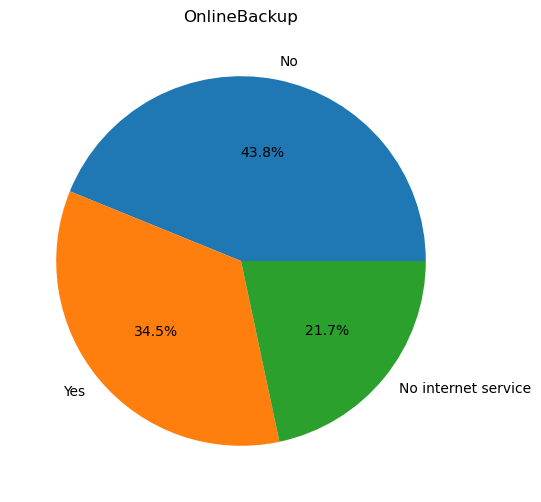

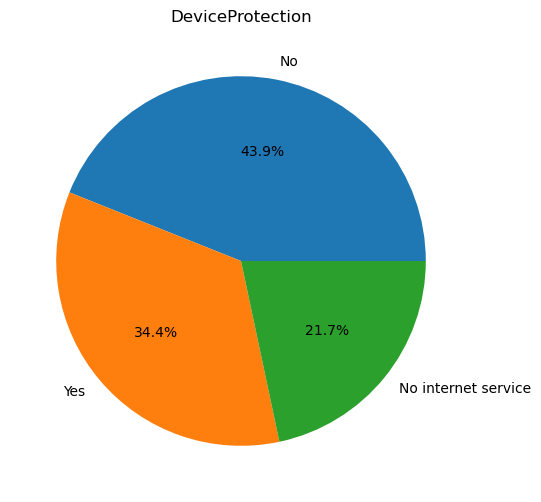

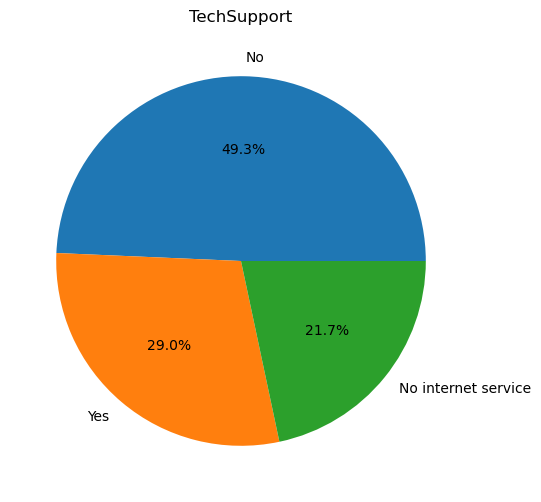

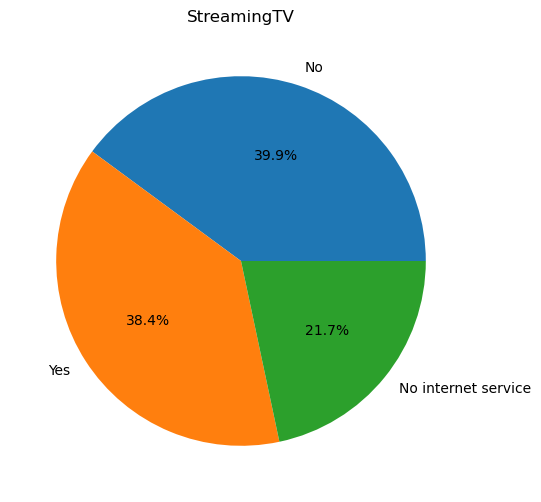

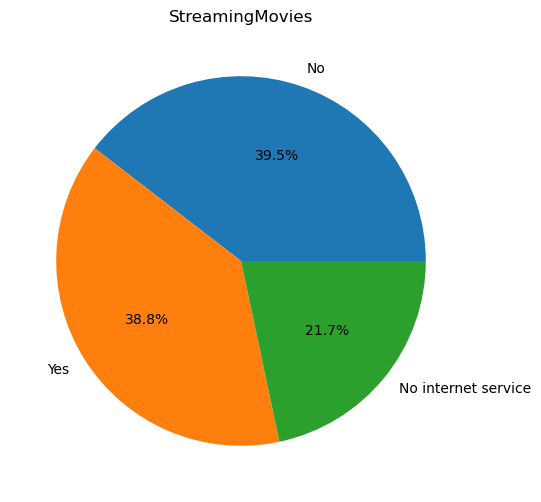

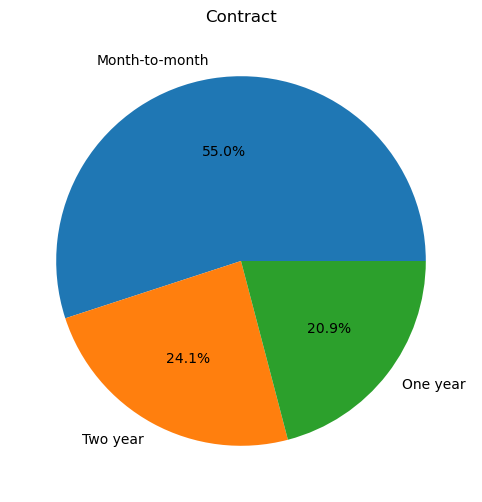

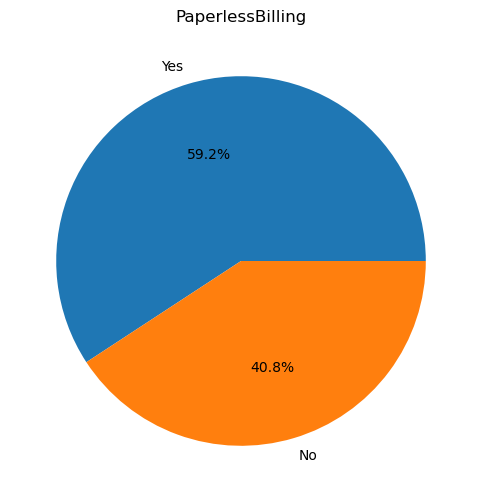

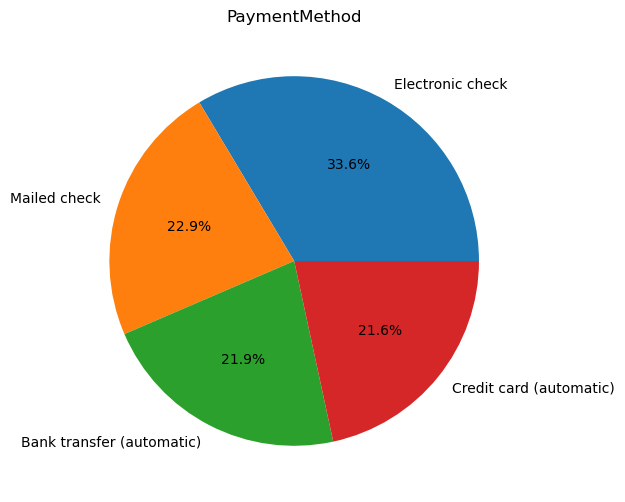

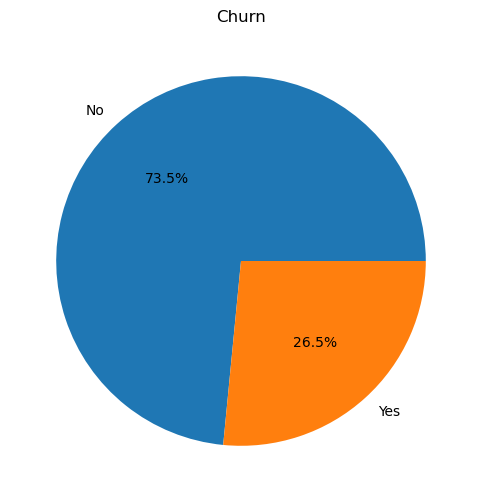

In [30]:
##============ Visualisation des variables catégorielles ============

for col in df.select_dtypes("object"):
    plt.figure(figsize=(8, 6))

    df[col].value_counts().plot.pie(autopct="%1.1f%%", ylabel="")
    plt.title(col)
    plt.show()

## Analyse Bivariée:
- **profiles_clients/target** :
    - On oserve le taux de churn est plus élevé chez les jeunes et parallèlement aussi les hommes churn plus
    - les clients avec des partenaires et ceux qui ont des gens qui dépendent d'eux quitte moins 
- **services_souscr_equ/target** :
    - étrangement les clients sans service téléphonique ont un taux de churn plus faible (hypothèse à vérifier)
    - et pour ceux abonnés à un service internet, ceux qui ont choisis l'option DSL, churn le moins propablement lié au              tarif(qui coûte en général moins chère que la fibre)
    - et ceux qui sont abonnés au Services additionnels ont un taux de churn plus faible en général (OnlineBackup,                 StreamTV,...)
- **dimentions_fin/target** :
    - les clients qui optent la facturation dématérialiser churn plus
    - et les modes de règlement où le taux de churn est plus faible est le règlement automatisé soit par carte bancaire ou         transfert bancaire
- **charges_clients/target** : On observes que les distributions des variables `MonthlyCharges`, `TotalCharges`, et `tenure`,    sont radicalement diffèrentes selon qu'on fasse partie du groupe des churners ou pas, et aucune d'elle suit une                distribution normale
- **contract/target** : on observe logiquement que le taux de churn est plus élevé quand le contrat est court

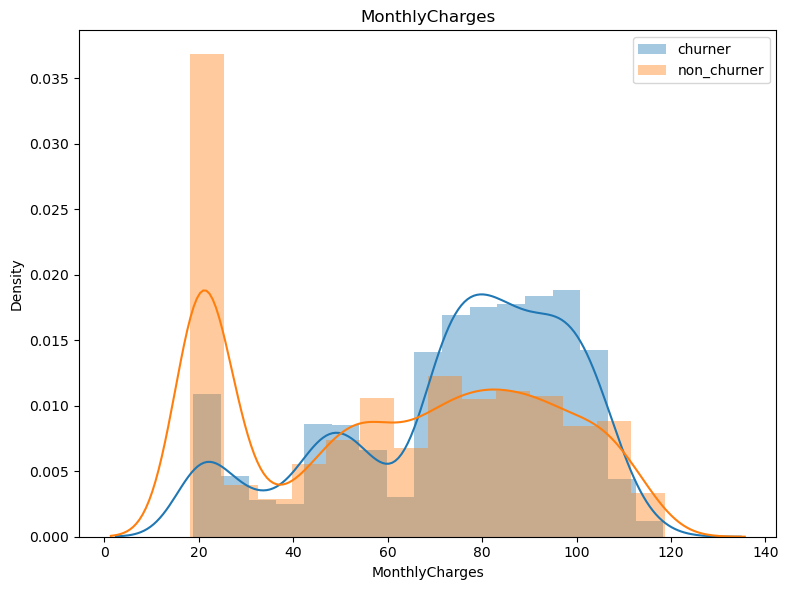

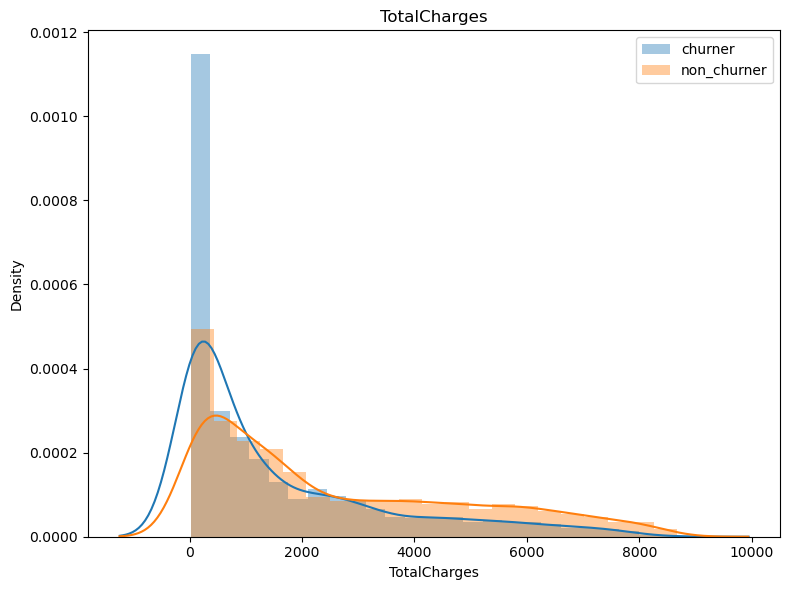

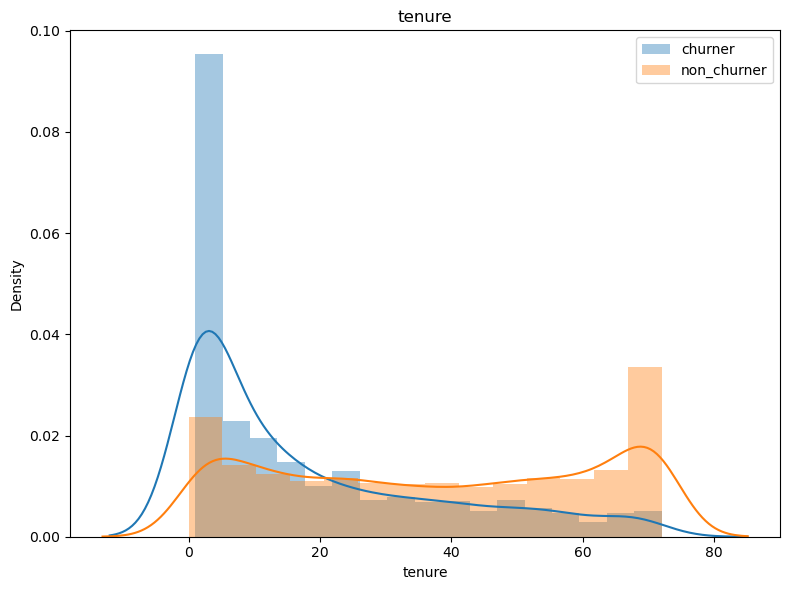

In [31]:
##============ visualisation profil_clients/target ==============
for col in charges_clients:
    plt.figure(figsize=(8, 6))

    sns.distplot(churner_df[col], label="churner", kde=True, bins= "fd")
    sns.distplot(non_churner_df[col], label="non_churner", kde=True, bins= "fd")

    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

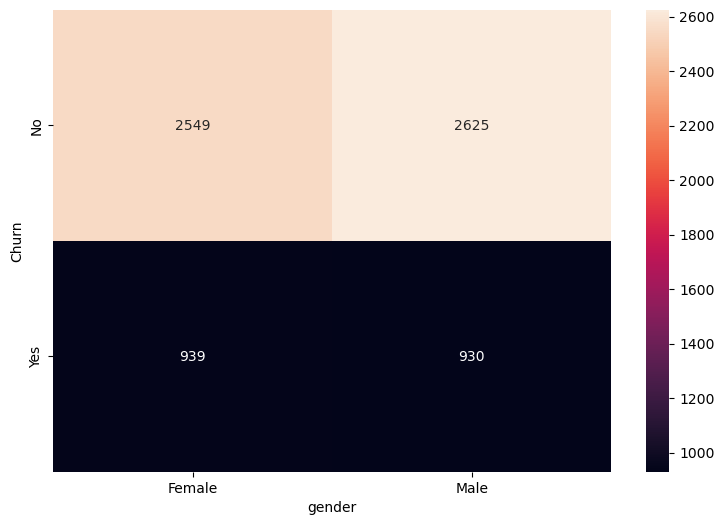

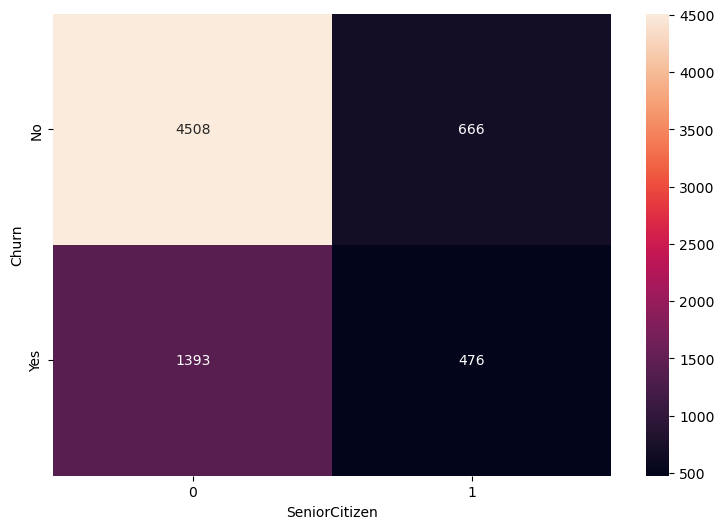

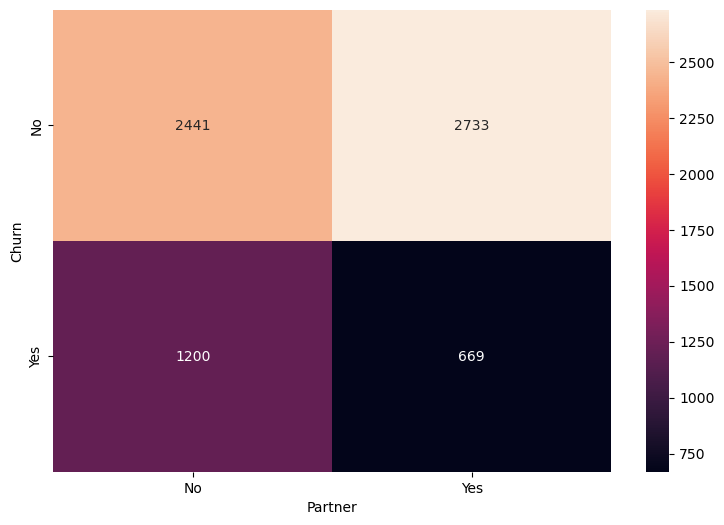

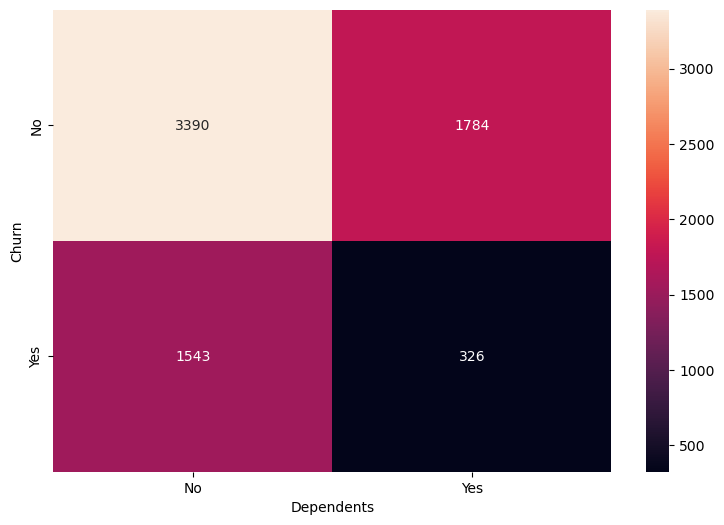

In [32]:
##================== Profile clients/ target ==============

for col in profiles_clients:
    plt.figure(figsize=(9, 6))
    sns.heatmap(pd.crosstab(df["Churn"], df[col]), annot=True, fmt='d')
    

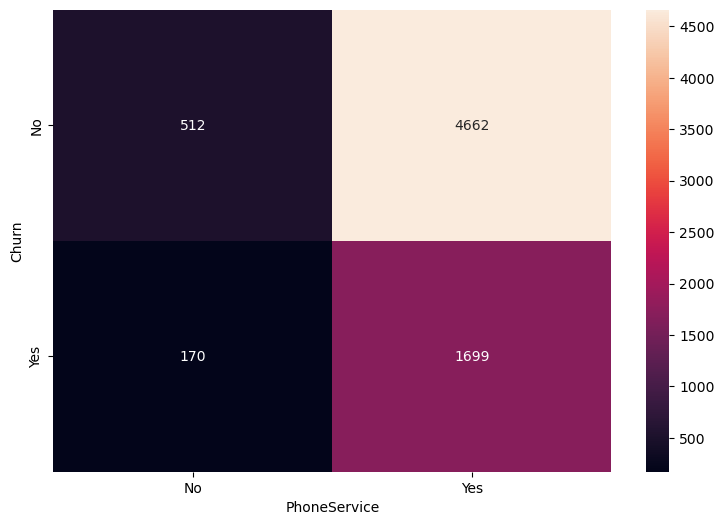

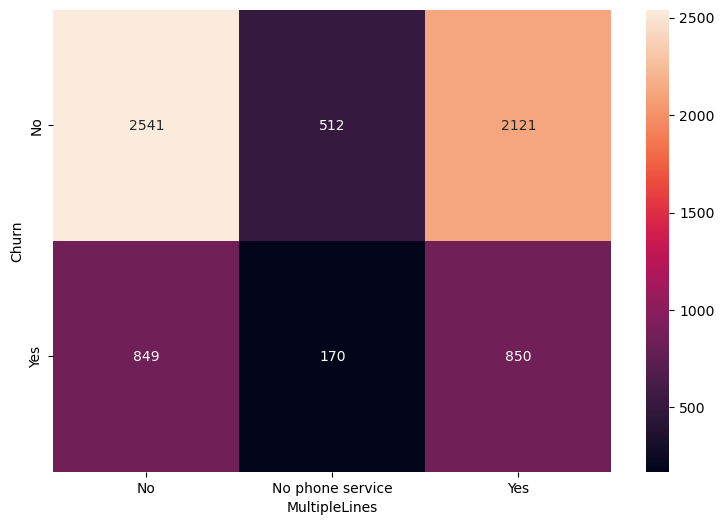

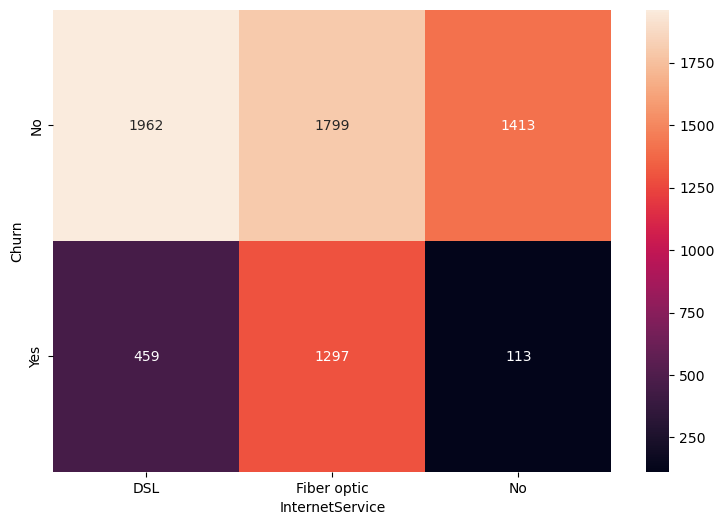

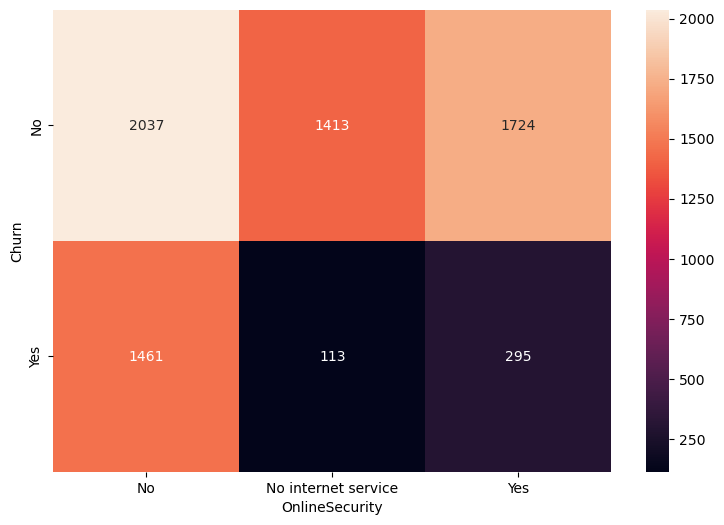

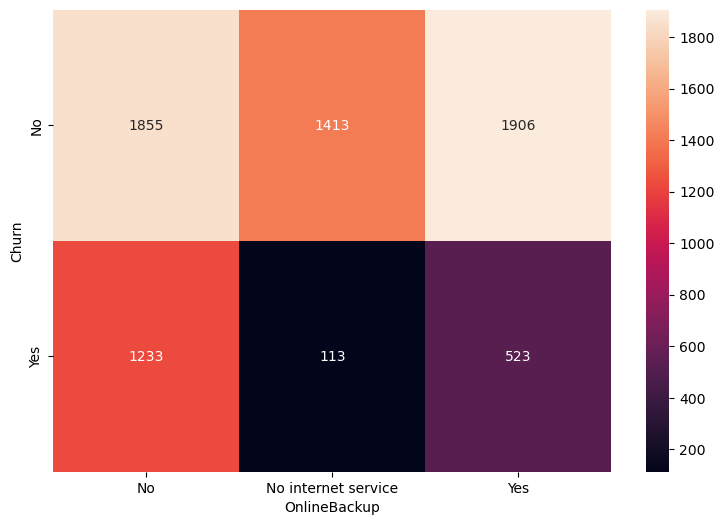

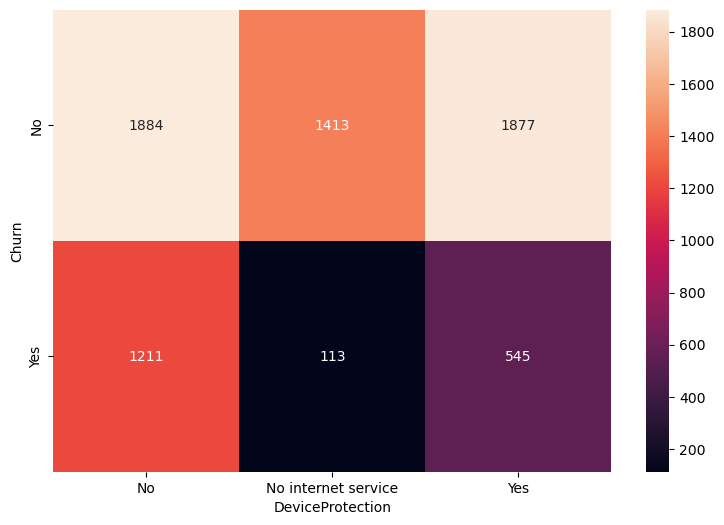

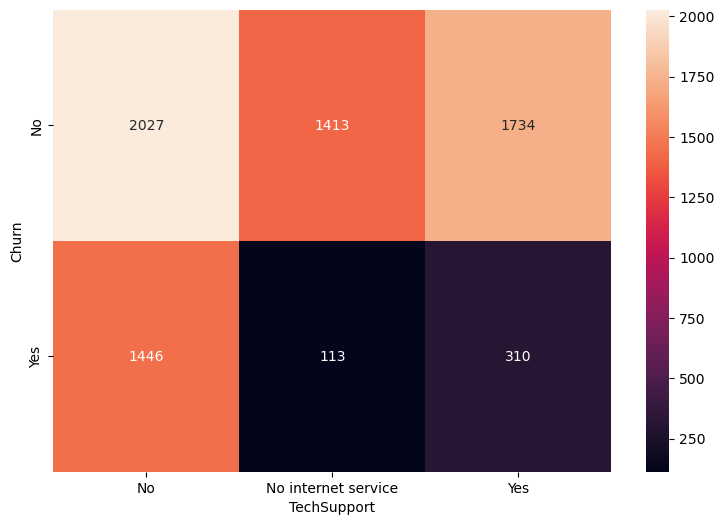

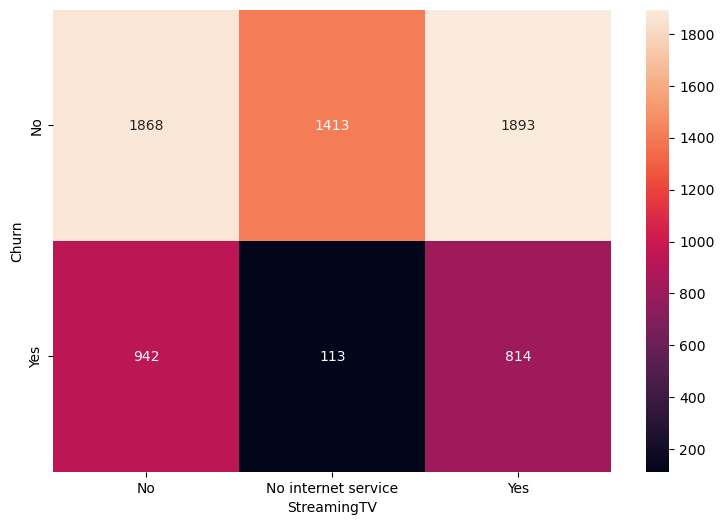

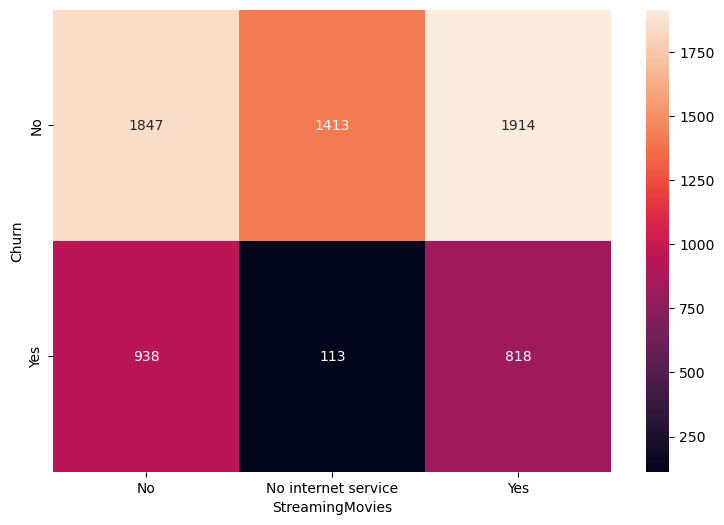

In [33]:
##================== services_souscr_equ/ target ==============

for col in services_souscr_equ:
    plt.figure(figsize=(9, 6))
    sns.heatmap(pd.crosstab(df["Churn"], df[col]), annot=True, fmt='d')

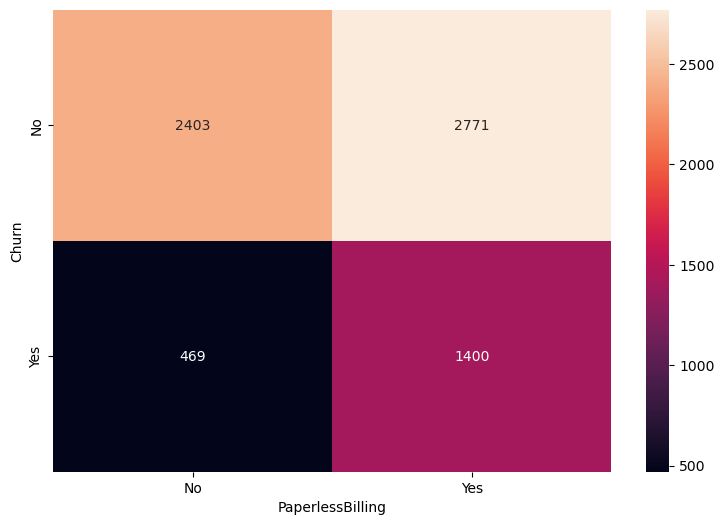

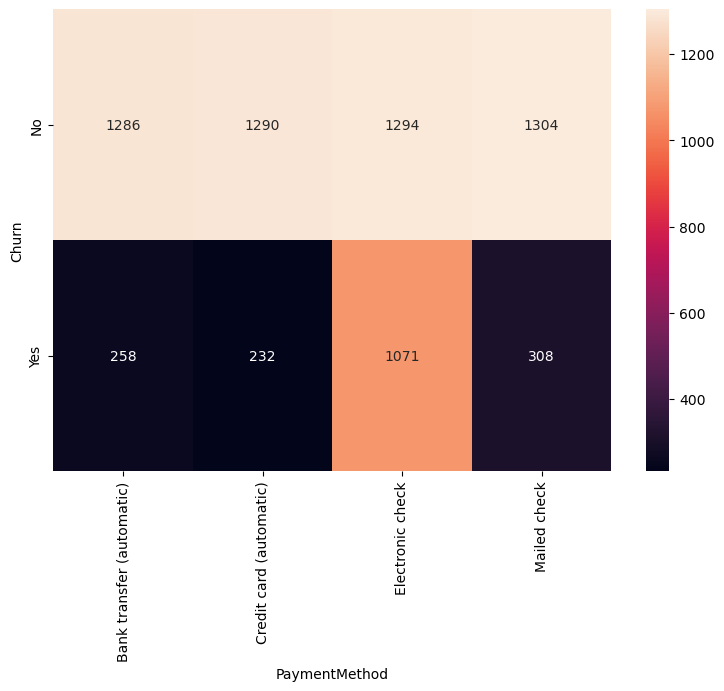

In [34]:
##================== dimensions_fin/ target ==============

for col in dimensions_fin:
    plt.figure(figsize=(9, 6))
    sns.heatmap(pd.crosstab(df["Churn"], df[col]), annot=True, fmt='d')

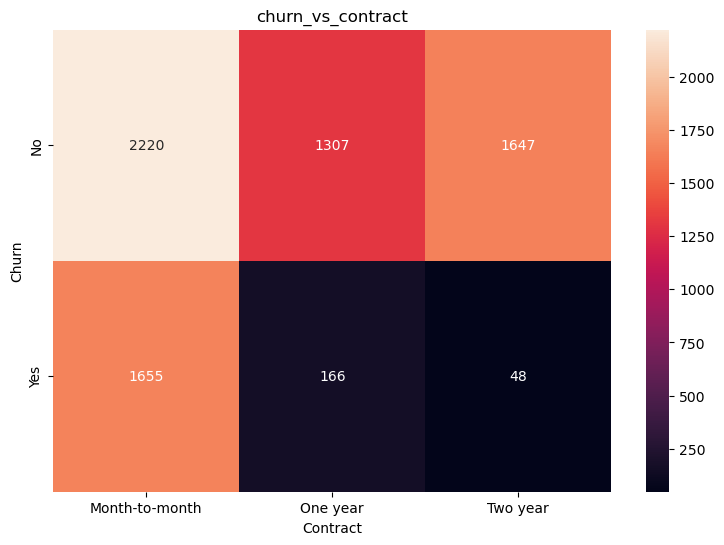

In [35]:
##================== Profile clients/ target ==============

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))
sns.heatmap(pd.crosstab(df["Churn"], df["Contract"]), annot=True, fmt='d')
plt.title("churn_vs_contract")
plt.savefig(figures_dir / "churn_vs_contract.png", bbox_inches="tight")

plt.show()

In [37]:
##================= Tableau comparatif de churn_by_contract========

churn_by_contract = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
).round(2)

churn_by_contract.to_csv("../reports/tables/churn_by_contract.csv")
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


## Corrélation entre les variables numériques:
- On obserble qu'on a une bonne corrélation entre `tenure` et `TotalCharges`,
- de même on observe une corrélation entre `MonthlyCharges` et `TotalCharges`
- Cependant on observe pas une corrélation nétte entre `tenure`et `MonthlyCharges`

In [38]:
df[charges_clients].corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651065,0.24790
TotalCharges,0.651065,1.000000,0.82588
tenure,0.247900,0.825880,1.00000


<Axes: >

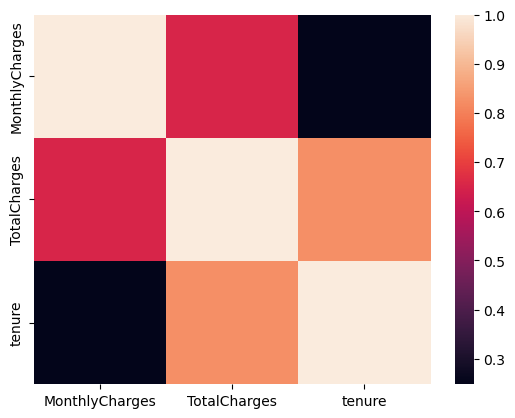

In [39]:
##====== visualisation avec la méthode heatmap ==========

sns.heatmap(df[charges_clients].corr())

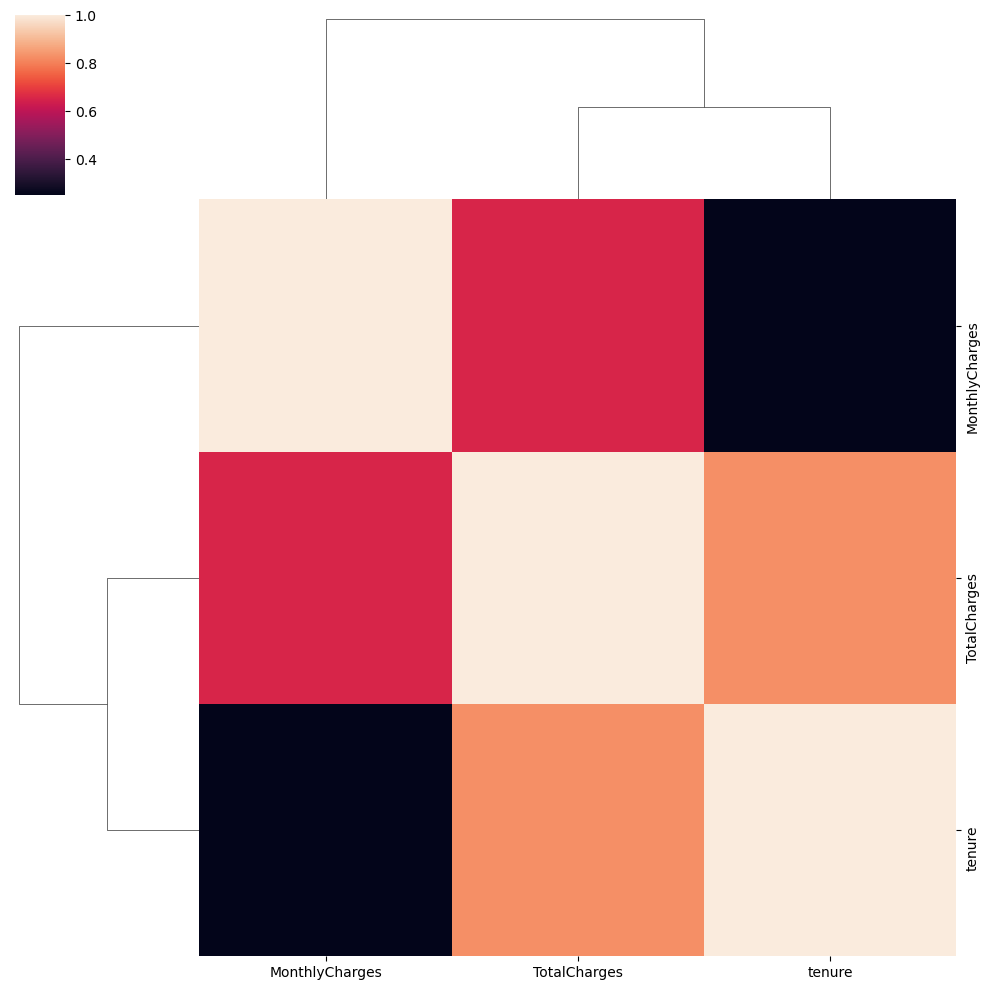

In [40]:
##====== visualisation avec la méthode clustersmap ==========

sns.clustermap(df[charges_clients].corr())

# Hypothèses et Tests statiques

In [41]:
##====== Quelques modules de base ==========
from scipy.stats import mannwhitneyu, chi2_contingency

## Cas 1: Variables numerique vs Churn:
- On observe un lien significatif entre le `churn` et les variables `tenure`, `MonthlyCharges`
- Cependant on a pas de lien claire entre le `churn` et la variable `TotalCharges`
## Cas 2: Variables catégorielles vs Churn:
- Parmis les variables catégorielles il y a qu'avec les variables `PhoneService` et `gender` où on observe pas de lien claire
   confirmant ainsi une de mes analyse au début de l'EDA, que j'avoue avoir trouvé étrange

In [42]:
##==== Variables numeriques =========
def test_mann (col):
    alpha = 0.05
    stat, p= mannwhitneyu(churner_df[col], non_churner_df[col])
    if p < alpha:
        return "lien significatif"
    else :
        return "pas de lien clair"
    

In [43]:
##============== Variables catégorielles =========
def test_ch2 (col):
    alpha = 0.05
    tab = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(tab)
    if p < alpha:
        return "lien significatif"
    else :
        return "pas de lien clair"
    
    

In [44]:
for col in df.select_dtypes(include = ["number"]).columns:
    print(f'{col :-<50} {test_mann(col)}')

SeniorCitizen------------------------------------- lien significatif
tenure-------------------------------------------- lien significatif
MonthlyCharges------------------------------------ lien significatif
TotalCharges-------------------------------------- pas de lien clair


In [45]:
for col in df.select_dtypes("object").columns:
    print(f'{col:-<50} {test_ch2(col)}')

gender-------------------------------------------- pas de lien clair
Partner------------------------------------------- lien significatif
Dependents---------------------------------------- lien significatif
PhoneService-------------------------------------- pas de lien clair
MultipleLines------------------------------------- lien significatif
InternetService----------------------------------- lien significatif
OnlineSecurity------------------------------------ lien significatif
OnlineBackup-------------------------------------- lien significatif
DeviceProtection---------------------------------- lien significatif
TechSupport--------------------------------------- lien significatif
StreamingTV--------------------------------------- lien significatif
StreamingMovies----------------------------------- lien significatif
Contract------------------------------------------ lien significatif
PaperlessBilling---------------------------------- lien significatif
PaymentMethod---------------------

In [46]:
results = pd.DataFrame({
    "variable": ["tenure", "MonthlyCharges", "Contract"],
    "test": ["Mann-Whitney", "Mann-Whitney", "Chi2_contingency"],
    "p_value": [0.001, 0.02, 0.0001],
    "significantif": [True, True, True]
})

results.to_csv("../reports/tables/stat_tests_summary.csv", index=False)
results

,variable,test,p_value,significantif
0,tenure,Mann-Whitney,0.0010,True
1,MonthlyCharges,Mann-Whitney,0.0200,True
2,Contract,Chi2_contingency,0.0001,True


# Conclusion Audite et EDA

## Audite des données:
Après une audite assez approfondîtes, on a pu apprendre beaucoup de chose sur nos données:   

- D'abord par rapport à la structure globale, on a un dataset avec un nombre de caractéristiques relativement faible (21         features), ce qui est un avantage quelque part car ça facilite un peu la compréhension de nos données, mais avec un            nombres de lignes ou d'echantillons lui important relativement (7043 samples);
- On compte très peu de valeurs manquantes (11 Nan), donc un dataset assez propre autrement dit moins de travail de nettoyage,   et plus de données pour le modèle;
- On observe aussi une cohérence générale des données.

## EDA
Une exploration de nos données m'a permis:

- De distinguer deux groupes de variables, un groupe qui sert plus à la description avec peu de valeur métier autrement dit      peu intéressant pour notre modèle (gender, SeniorCitizen, Dependent, Partner) et un deuxième groupe constitué par le reste     des caractéristiques, qui reflétent un intérêt métier plus visible en pariculier;
- D'extraire quelques informations actionnables:

    - **Variables importantes** : Contract, tenure, MonthlyCharges, PaymentMethod, TechSupport
    - **Insight clés** : on observe un nombre de clients récents plus élevés, donc un churn plus probable et  plus de contrats         mensuels, et la conséquence directe est d'avoir un taux de clients à risque important
      
- On suppose donc qu'il serait intéressant de cibler en particulier les clients dont les modalités sur le deuxième groupe de    carterisques laisse à désirer.
  
En résumé vu ce qu'on vient d'apprendre et par rapport à l'objectif qu'on s'est fixer dans ce projet, dans la partie preprocessing, on se focalisera plus sur les autres parties (encodage, normalisation, features engineering, ...) que la partie nettoyage. Et surtout mettre l'accent sur le deuxième groupe de variables.

